In [4]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
cmap = plt.cm.get_cmap('RdYlBu_r')

/var/folders/7w/k64x4hxx1x96s_hxn35hcg0w0000gp/T/ipykernel_91430/1635236098.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlBu_r')


In [1]:
import numpy as np
import netCDF4 as nc
import os
from datetime import datetime, timedelta

In [3]:
Observation_indir  = '/storage1/fs1/rvmartin2/Active/yany1/1.project/NO2_DL_global_2019/data/monthly_observation/'
infile = Observation_indir + 'no2_monthly_observations_v0.0.2.nc'
data = nc.Dataset(infile)

# Convert dates to datetime objects
base_date = datetime(2005, 1, 1)
days_since = data['dates'][:]  # shape = (228,)
all_dates = np.array([base_date + timedelta(days=int(d)) for d in days_since])

# Filter indices matching the target year
time_mask = np.array([dt.year == 2019 for dt in all_dates])
if not np.any(time_mask):
    raise ValueError(f"No data found for year {year}.")

# Extract relevant data
SPECIES_OBS = data['NO2'][:, time_mask]  # shape = (9728, N_months_for_year)
sites_number = SPECIES_OBS.shape[0]
lat = data["latitude"][:]
lon = data["longitude"][:]

In [4]:
years = ['2019', '2020']
# Ensure nput is a list of integers
if isinstance(years, (str, int)):
    years = [int(years)]
else:
    years = [int(y) for y in years]

infile = Observation_indir + 'no2_monthly_observations_v0.0.2.nc'
data = nc.Dataset(infile)

# Convert time axis to datetime
base_date = datetime(2005, 1, 1)
days_since = data['dates'][:]  # shape: (228,)
all_dates = np.array([base_date + timedelta(days=int(d)) for d in days_since])

# Build time mask for all selected years
time_mask = np.array([dt.year in years for dt in all_dates])
if not np.any(time_mask):
    raise ValueError(f"No data found for years: {years}")

# Extract subset and basic metadata
SPECIES_OBS = data['NO2'][:, time_mask]  # shape: (n_sites, n_selected_months)
sites_number = SPECIES_OBS.shape[0]
lat = data["latitude"][:]
lon = data["longitude"][:]


In [6]:
x = np.load('/Volumes/rvmartin2/Active/yany1/1.project/NO2_DL_US_2019/NO2_US_pkg/input_variables/tSATLON_US_MAP.npy')
y = np.load('/Volumes/rvmartin2/Active/yany1/1.project/NO2_DL_US_2019/NO2_US_pkg/input_variables/tSATLAT_US_MAP.npy')

In [3]:
InDir = '/Volumes/rvmartin2/Active/yany1/1.project/NO2_DL_US_2019/TrainingDatasets/US_NO2-v0.0.0/'
TrainingDatasets= xr.open_dataset(InDir + 'cnn_TrainingData_188channels_11x11_201901-201912.nc')
print(TrainingDatasets)

<xarray.Dataset> Size: 21MB
Dimensions:              (unity: 1, Total_Number: 5340, width: 11, height: 11)
Coordinates:
    width                (unity) int32 4B ...
    height               (unity) int32 4B ...
Dimensions without coordinates: unity, Total_Number
Data variables:
    sites_number         (unity) int32 4B ...
    Total_number         (unity) int32 4B ...
    start_YYYY           (unity) int32 4B ...
    end_YYYY             (unity) int32 4B ...
    GeoNO2_Hour-13-15    (Total_Number, width, height) float64 5MB ...
    GCHP_NO2_Hour-13-15  (Total_Number, width, height) float64 5MB ...
    GeoNO2_24Hours       (Total_Number, width, height) float64 5MB ...
    GCHP_NO2_24Hours     (Total_Number, width, height) float64 5MB ...
Attributes:
    TITLE:           Monthly Training Datasets for training for NO2 over US
    VariableList:    ['GeoNO2_Hour-13-15', 'GCHP_NO2_Hour-13-15', 'GeoNO2_24H...
    TIMERESOLUTION:  Monthly
    TIMECOVERAGE:    201901-201912


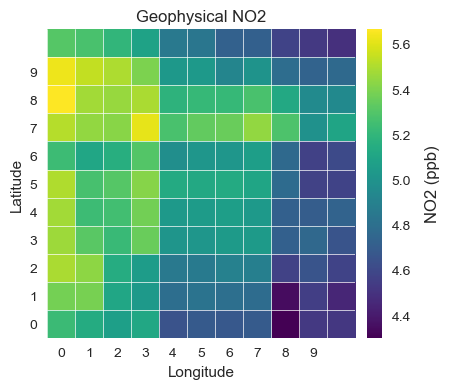

In [10]:
# Create a figure with multiple subplots
fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(TrainingDatasets['GeoNO2_24Hours'][0].values, cmap='viridis', aspect='equal')
ax.set_title('Geophysical NO2')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('NO2 (ppb)', fontsize=12, labelpad=10)
# Set ticks at pixel centers (offset by 0.5)
xticks = np.arange(-0.5, 10.5, 1)  # Grid lines between pixels
yticks = np.arange(-0.5, 10.5, 1)
ax.set_xticks(xticks, minor=True)
ax.set_yticks(yticks, minor=True)

# Set major ticks at pixel centers
ax.set_xticks(np.arange(0, 10, 1))
ax.set_yticks(np.arange(0, 10, 1))

# Set limits to show full pixels
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.5, 10.5)

# Add grid at pixel boundaries
ax.grid(True, which='minor', color='white', linestyle='-', linewidth=0.5)
ax.grid(False, which='major')  # Turn off major grid

plt.tight_layout()
plt.show()

In [11]:
var = 'Geophysical_NO2'
var_values = ds[var][1000,:,:]

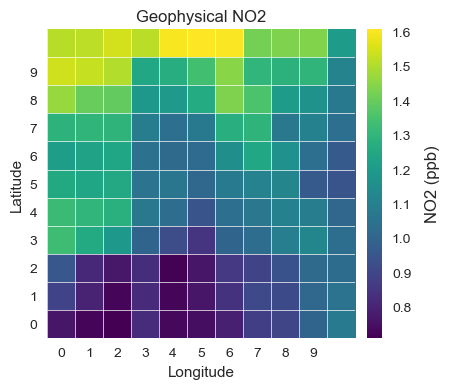

In [ ]:
# Create a figure with multiple subplots
fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(var_values, cmap='viridis', aspect='equal')
ax.set_title('Geophysical NO2')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('NO2 (ppb)', fontsize=12, labelpad=10)
# Set ticks at pixel centers (offset by 0.5)
xticks = np.arange(-0.5, 10.5, 1)  # Grid lines between pixels
yticks = np.arange(-0.5, 10.5, 1)
ax.set_xticks(xticks, minor=True)
ax.set_yticks(yticks, minor=True)

# Set major ticks at pixel centers
ax.set_xticks(np.arange(0, 10, 1))
ax.set_yticks(np.arange(0, 10, 1))

# Set limits to show full pixels
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.5, 10.5)

# Add grid at pixel boundaries
ax.grid(True, which='minor', color='white', linestyle='-', linewidth=0.5)
ax.grid(False, which='major')  # Turn off major grid

plt.tight_layout()
plt.show()

In [24]:
print(f"Array shape: {ds.shape}")
print(f"Data type: {ds.dtype}")
print(f"\nStatistics:")
print(f"Min: {np.nanmin(ds):.2e}")
print(f"Max: {np.nanmax(ds):.2e}")
print(f"Mean: {np.nanmean(ds):.2e}")
print(f"Median: {np.nanmedian(ds):.2e}")
print(f"NaN count: {np.isnan(ds).sum()}")
print(f"NaN percentage: {(np.isnan(ds).sum() / ds.size) * 100:.2f}%")

Array shape: (4920, 11, 11)
Data type: float64

Statistics:
Min: 1.31e-01
Max: 1.48e+02
Mean: 8.60e+00
Median: 6.02e+00
NaN count: 5066
NaN percentage: 0.85%


In [28]:
import xarray as xr
siyuan_path = '/Volumes/rvmartin2/Active/yany1/deep_learning/training_files/'
siyuan_ds = xr.open_dataset(siyuan_path + 'PM25-cnn_TrainingData_59channels_11x11_199801-202212_BenchMark.nc')

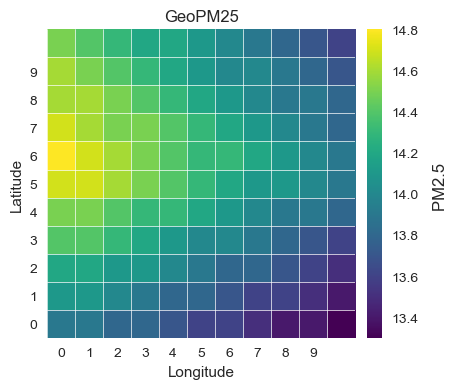

In [45]:
var = 'GeoPM25'
var_values = siyuan_ds[var][50000,:,:]
fig, ax = plt.subplots(figsize=(6, 4))


# Plot the data
im = ax.imshow(var_values, cmap='viridis', aspect='equal', vmin=np.nanmin(var_values), vmax=np.nanmax(var_values))

# Set title and labels
ax.set_title(f'{var}')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('PM2.5 ', fontsize=12, labelpad=10)

# Set ticks at pixel centers (offset by 0.5)
xticks = np.arange(-0.5, 10.5, 1)  # Grid lines between pixels
yticks = np.arange(-0.5, 10.5, 1)
ax.set_xticks(xticks, minor=True)
ax.set_yticks(yticks, minor=True)

# Set major ticks at pixel centers
ax.set_xticks(np.arange(0, 10, 1))
ax.set_yticks(np.arange(0, 10, 1))

# Set limits to show full pixels
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.5, 10.5)

# Add grid at pixel boundaries
ax.grid(True, which='minor', color='white', linestyle='-', linewidth=0.5)
ax.grid(False, which='major')  # Turn off major grid

plt.tight_layout()
plt.show()

In [35]:
RoadDir = '/Volumes/rvmartin2/Active/yany1/1.project/NO2_US_pkg/input_variables/OpenStreetMap_RoadDensity_NearestDistances_forEachPixels_input/major_roads/'
RoadFile = RoadDir + 'OpenStreetMap-major_roads-NearestDistanceforEachPixel_001x001_US_2025.npy'
RoadData = np.load(RoadFile)

x = np.load('/Volumes/rvmartin2/Active/yany1/1.project/NO2_US_pkg/input_variables/tSATLON_US_MAP.npy')
y = np.load('/Volumes/rvmartin2/Active/yany1/1.project/NO2_US_pkg/input_variables/tSATLAT_US_MAP.npy')

In [ ]:
print("Type of RoadData:", type(RoadData))
print("\nShape of RoadData:", RoadData.shape)
print("\nFirst few values of RoadData:")
print(RoadData[:5] if hasattr(RoadData, '__len__') else RoadData)

In [36]:
print("x (lat) shape:", x.shape)
print("y (lon) shape:", y.shape)
print("RoadData shape:", RoadData.shape)
print("\nLatitude range:", x.min(), "to", x.max())
print("Longitude range:", y.min(), "to", y.max())
print("\nSample of x:", x[0:5, 0:5])
print("\nSample of y:", y[0:5, 0:5])

x (lat) shape: (6000, 10000)
y (lon) shape: (6000, 10000)
RoadData shape: (6001, 10001)

Latitude range: -139.995 to -40.005
Longitude range: 10.005 to 69.995

Sample of x: [[-139.995 -139.985 -139.975 -139.965 -139.955]
 [-139.995 -139.985 -139.975 -139.965 -139.955]
 [-139.995 -139.985 -139.975 -139.965 -139.955]
 [-139.995 -139.985 -139.975 -139.965 -139.955]
 [-139.995 -139.985 -139.975 -139.965 -139.955]]

Sample of y: [[10.005 10.005 10.005 10.005 10.005]
 [10.015 10.015 10.015 10.015 10.015]
 [10.025 10.025 10.025 10.025 10.025]
 [10.035 10.035 10.035 10.035 10.035]
 [10.045 10.045 10.045 10.045 10.045]]


In [26]:
print("RoadData min:", np.nanmin(RoadData))
print("RoadData max:", np.nanmax(RoadData))
print("\nSample of RoadData (top-left corner):")
print(RoadData[0:5, 0:5])
print("\nSample of RoadData (where values > 0):")
print("Number of non-zero values:", np.count_nonzero(RoadData))
print("Locations of some non-zero values:", np.where(RoadData > 0)[0][:5], np.where(RoadData > 0)[1][:5])

RoadData min: 0.0
RoadData max: 5226.711563108256

Sample of RoadData (top-left corner):
[[2831.51935845 2831.04078472 2830.562501   2830.08450743 2829.60680417]
 [2830.51932828 2830.04061146 2829.56218469 2829.0840481  2828.60620185]
 [2829.51937608 2829.04051609 2828.56194618 2828.0836665  2827.60567718]
 [2828.51950193 2828.0404987  2827.56178557 2827.08336271 2826.60523025]
 [2827.51970591 2827.04055935 2826.56170293 2826.08313681 2825.60486112]]

Sample of RoadData (where values > 0):
Number of non-zero values: 59551037
Locations of some non-zero values: [0 0 0 0 0] [0 1 2 3 4]


x (longitude) first row: [-140.   -139.99 -139.98 -139.97 -139.96]
y (latitude) first column: [10.   10.01 10.02 10.03 10.04]

RoadData shape: (6001, 10001)
Coordinate ranges:
Longitude (x): -140.000 to -40.000
Latitude (y): 10.000 to 70.000


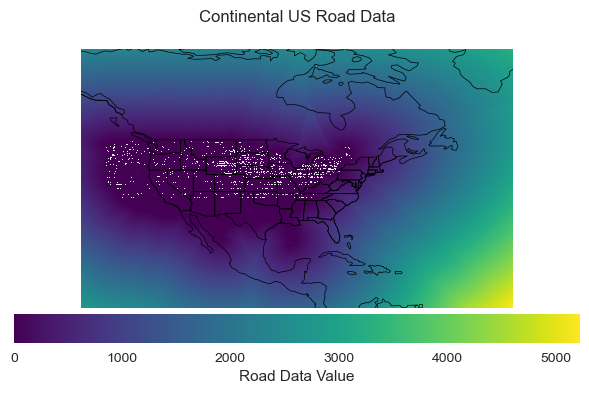

In [ ]:
# Print a few more details about coordinates
print("x (longitude) first row:", x[0,:5])  # Should increase from left to right
print("y (latitude) first column:", y[:5,0])  # Should increase from bottom to top
print("\nRoadData shape:", RoadData.shape)
print("Coordinate ranges:")
print(f"Longitude (x): {x.min():.3f} to {x.max():.3f}")
print(f"Latitude (y): {y.min():.3f} to {y.max():.3f}")

In [33]:
print("Original x (loaded) range:", x.min(), "to", x.max())
print("Original y (loaded) range:", y.min(), "to", y.max())
print("\nShape of loaded coordinates:")
print("x shape:", x.shape)
print("y shape:", y.shape)

# Let's also check some values from different parts of the arrays
print("\nSamples from x array:")
print("Left edge:", x[0,0], "Middle:", x[0,5000], "Right edge:", x[0,-1])
print("\nSamples from y array:")
print("Bottom edge:", y[0,0], "Middle:", y[3000,0], "Top edge:", y[-1,0])

Original x (loaded) range: -140.0 to -40.00000000009095
Original y (loaded) range: 10.0 to 69.99999999999872

Shape of loaded coordinates:
x shape: (6001, 10001)
y shape: (6001, 10001)

Samples from x array:
Left edge: -140.0 Middle: -90.00000000004547 Right edge: -40.00000000009095

Samples from y array:
Bottom edge: 10.0 Middle: 39.99999999999936 Top edge: 69.99999999999872


In [31]:
# Create new coordinate arrays
lon = np.linspace(-140, -40, 10001)  # Longitude, matching the data width
lat = np.linspace(10, 70, 6001)      # Latitude, matching the data height
lon_grid, lat_grid = np.meshgrid(lon, lat)

In [37]:
fig, ax = plt.subplots(figsize=(6, 4), 
                       subplot_kw={'projection': ccrs.PlateCarree()})

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.set_extent([-135, -50, 10, 60], crs=ccrs.PlateCarree())

mesh = ax.pcolormesh(x, y, RoadData,
                     transform=ccrs.PlateCarree(),
                     cmap='viridis',
                     vmin = np.nanmin(RoadData),
                     vmax = np.nanmax(RoadData),
                     shading='nearest')

# Add colorbar
cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.02)
cbar.set_label('Road Data Value')

# Add title
plt.title('Continental US Road Data', pad=20)

plt.tight_layout()
plt.show()

TypeError: Dimensions of C (6001, 10001) should be one smaller than X(10000) and Y(6000) while using shading='flat' see help(pcolormesh)